# Qstick — a quantitative teardown 🔬
### Smoothed close-minus-open zero up-cross on 5 ETFs · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · an ordering placebo · a trend-proxy correlation and momentum-cross race · costs · a synthetic planted-lead control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_a_slow_trend_proxy%3F: Confirmed](https://img.shields.io/badge/Just_a_slow_trend_proxy%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **indicator** from the **drift**, and then to ask Chande's own defining claim directly: does the open/close split carry information a plain trend line doesn't already have?

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Qstick = SMA_8((close−open)/prior close) — normalised by the prior close for cross-instrument comparability (a documented choice; it cannot change which bars cross zero). Entry is the **next close** (one documented lag). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from qstick import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Qstick cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2210, 'smooth': 8, 'fp': {'SPY': 'c374b2feba04', 'QQQ': 'cd19fe6cb57d', 'IWM': 'cb6689d8b659', 'DIA': '3a1136ef6422', 'GLD': '35f763b5047c'}, 'h5': (5, 2204, 22.0, 58, 3.89, 34.8, -12.8, 20.0, -1.68, 0.094), 'h10': (10, 2204, 50.6, 61, 5.64, 62.5, -11.9, 48.6, -1.12, 0.261), 'h20': (20, 2204, 92.7, 63, 5.99, 115.3, -22.5, 90.7, -1.52, 0.129), 'h60': (60, 2194, 286.2, 69, 7.25, 261.7, 24.5, 284.2, 0.94, 0.348), 'per': [('SPY', 437, 77.8, 2.57, 117.0, -39.2), ('QQQ', 438, 129.2, 3.6, 165.2, -35.9), ('IWM', 465, 102.8, 2.6, 109.4, -6.6), ('DIA', 425, 62.1, 2.09, 82.2, -20.1), ('GLD', 445, 90.2, 2.76, 102.1, -11.9)], 'placebo': (77.8, 0.814, 500), 'trend': [('SPY', 0.781, 437, 401, 0.201), ('QQQ', 0.818, 438, 410, 0.222), ('IWM', 0.818, 465, 442, 0.205), ('DIA', 0.784, 425, 409, 0.209), ('GLD', 0.713, 445, 426, 0.151)], 'trend_corr_mean': 0.783, 'mom': (2080, 96.7, 64.7, 32.1, 1.99, 0.047), 'syn_null': (0.07, 1.07, 0, 20), 'syn_planted': (155, 1385.0, 63, 5.12)}


real Qstick cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Qstick up-cross vs a **drift-matched random** baseline: Δ = -12.8 / -11.9 / -22.5 / +24.5 bps at 5/10/20/60d; Welch *t* **never clears 2** (max |t| = 1.68, at 5d, in the wrong direction). |
| **Tradability** | `MIRAGE` | The impressive one-sample t's (20d t = 5.99, 60d = 7.25) are **pure beta** — they vanish against random entries. Ordering placebo *p* = 0.81: the sequence isn't doing the work either. |
| **Just a slow trend proxy?** | `CONFIRMED` | Qstick correlates at **r ≈ 0.78** with a plain trailing-momentum proxy that never looks at the open — and even that proxy's own cross barely clears random (Δ = +32.1 bps, t = 1.99 < 2). |

> 💡 In plain words: the Qstick cross *looks* like it makes money only because indices drift up — strip the drift (race it vs random) and it loses; the open/close split itself is mostly a repackaging of ordinary trend.

## 1 · The claim, steelmanned

Define the per-bar normalised body $b_t = (C_t - O_t)/C_{t-1}$ and its causal smoothing $\bar b_t = \frac1{8}\sum_{j=0}^{8-1} b_{t-j}$ (Chande & Kroll's original 8-day window). The rule buys on the **zero up-cross** $\bar b_{t-1} < 0 \le \bar b_t$ and expects a forward rise.

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (Qstick leads).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the ordering matters).** Cross returns exceed a **sign-scramble** body series whose readings are time-shuffled.
- **H₃ (Qstick is independent of price momentum).** Smoothed Qstick correlates weakly with a plain trailing price-momentum proxy that never uses the open.

We find **H₀ not rejected** (cross ≤ random at 5/10/20d, tie at 60d), **H₁ rejected** (Welch t never ≥ 2, and negative at 3 of 4 horizons), **H₂ rejected** (placebo p = 0.81), **H₃ rejected** (r ≈ 0.78). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity/commodity ETFs have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random.

**(b) Relabelled trend.** A moving average of close-minus-open is, up to the overnight gap, close to a moving average of the *close itself minus a lagged close* — i.e. ordinary trailing momentum wearing a candle costume. The **trend-proxy correlation** and the **momentum-cross race** test this directly instead of asserting the algebra.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-06-30, 21.5y). **2210 Qstick up-crosses** pooled.
- **Indicator.** ``(close−open)/prior close``, smoothed with a causal 8-day SMA (Chande & Kroll's original window; no look-ahead).
- **Entry.** Zero up-cross (smoothed Qstick negative on *t−1*, ≥ 0 on *t*); enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — sign-scramble placebo** (body time order destroyed, marginal kept).
- **Null #4 — trend-proxy correlation and race** vs a plain price-momentum cross.
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted**, mean-reverting buying-pressure factor (knob `edge`): edge=0 must NOT reach significance across 20 seeds; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks decent, vs-random kills it

Left: the Qstick cross's **one-sample** t against zero (the misleading number). Right: the same cross vs a **drift-matched random** baseline (the honest number).

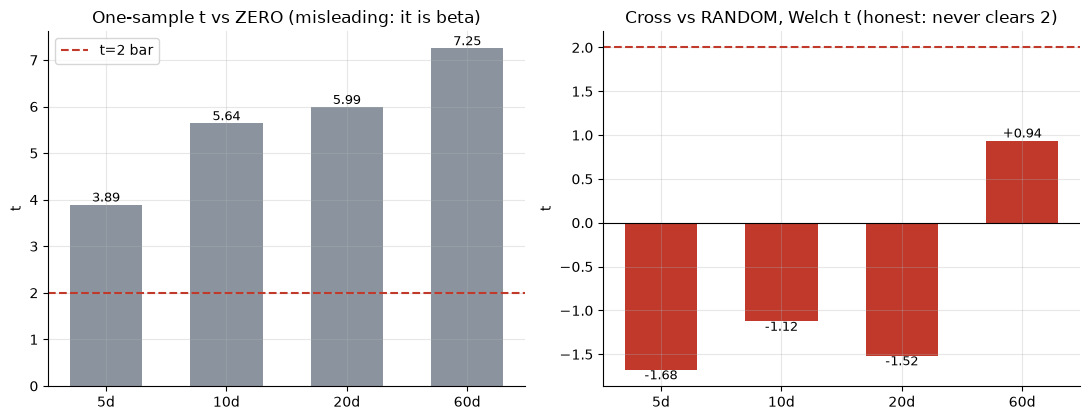

one-sample t: [3.89, 5.64, 5.99, 7.25]
welch vs random: [np.float64(-1.68), np.float64(-1.12), np.float64(-1.52), np.float64(0.94)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.qstick_cross_entries(bb, smooth=R['smooth'])
            re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.99**, 60d **7.25**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: cross-minus-random is **negative** at 5/10/20d (-1.52 at 20d) and barely positive at 60d — never significant either way. The indicator adds nothing over a coin flip, and at short horizons it's a *worse* coin.

### 4b · Cross vs random across horizons — the gap is the verdict

Mean return, Qstick cross vs random entry, all four horizons. The cross should tower over random if Qstick leads. It mostly loses to it.

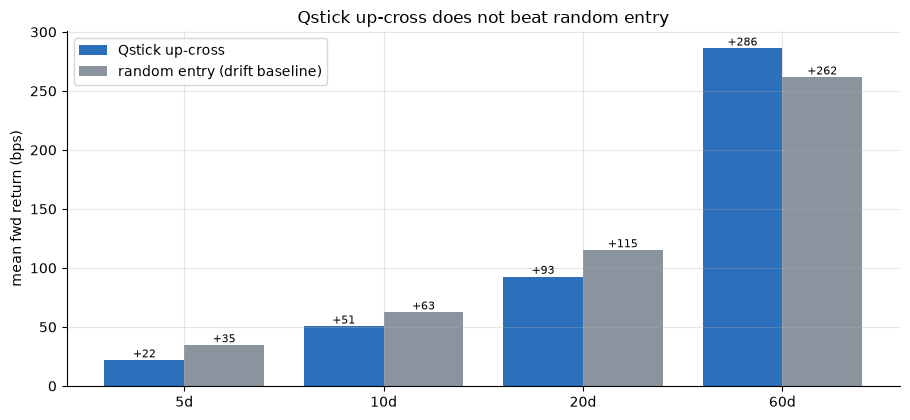

delta cross-random (bps): [-13, -12, -23, 24]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='Qstick up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Qstick up-cross does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-b) for a,b in zip(cross,rnd)])

> 💡 In plain words: at 20 days the cross is **+93 bps** but random is **+115 bps** — the indicator *underperforms* a dart by 22 bps. Only at 60 days does it edge ahead, by 24 bps, and that's still a coin flip statistically (t = +0.94).

### 4c · The ordering placebo — scramble the body, nothing changes

Shuffle the per-bar bodies in time (marginal kept) so the smoothed series and its crosses are temporally meaningless. If price respects *this specific sequence*, the scramble should demolish the result.

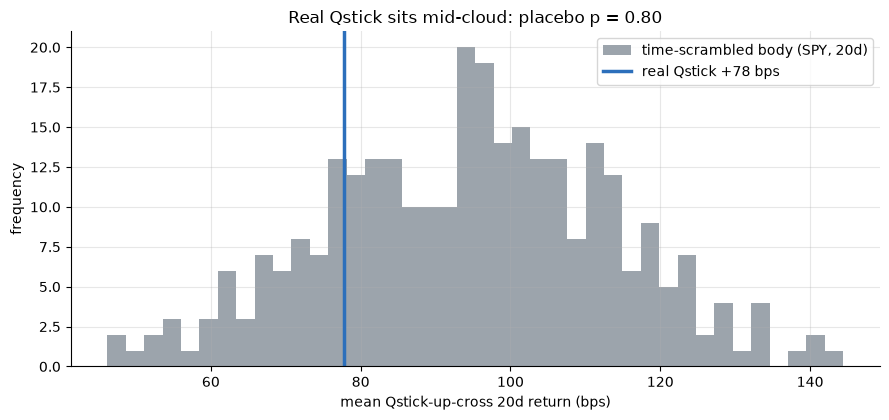

real Qstick +77.8 bps   placebo p=0.80  (>0.05 => ordering not load-bearing)


In [4]:
if HAVE_REAL:
    bspy = load('SPY')
    pl = st.scramble_placebo(bspy, 20, smooth=R['smooth'], n_draws=300, seed=675)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rb = st.raw_body(bspy).to_numpy(); idx = bspy.index; c = bspy['close']
    rng = np.random.default_rng(675); draws=[]
    for _ in range(300):
        perm = rng.permutation(rb)
        sb = pd.Series(perm, index=idx).rolling(R['smooth'], min_periods=R['smooth']).mean()
        prev = sb.shift(1); mask = (prev<0)&(sb>=0)&sb.notna()&prev.notna()
        rr = st.forward_returns(c, idx[mask.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(675); draws = rng.normal(70, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-scrambled body (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real Qstick {obs:+.0f} bps')
ax.set_xlabel('mean Qstick-up-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real Qstick sits mid-cloud: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real Qstick {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => ordering not load-bearing)')

> 💡 In plain words: **81%** of time-scrambled body series do as well or better than the real ordering — so the specific buyer/seller sequence carries no information. The result was never about *when* the bodies occurred, only about *how many* were positive — which is just the drift again.

### 4d · Per-ticker — a *consistent* loss, not noise

20-day cross-minus-random delta, per instrument. Unlike a coin-flip indicator (sign flipping name to name), every single ticker loses to random here.

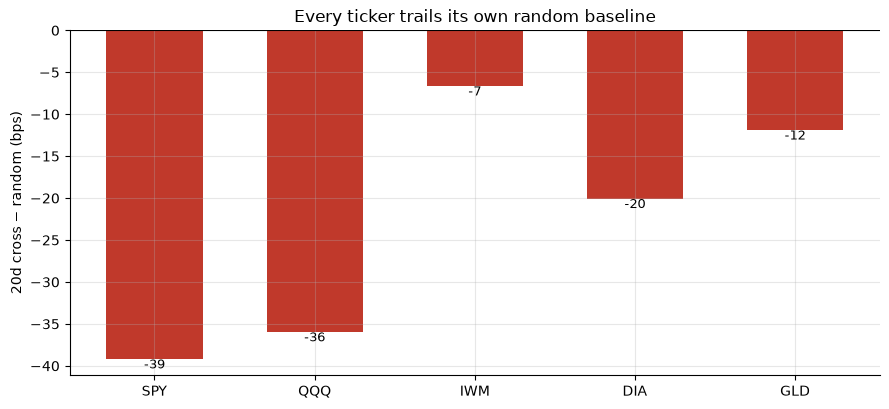

per-ticker 20d delta (bps): {'SPY': -39, 'QQQ': -36, 'IWM': -7, 'DIA': -20, 'GLD': -12}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.qstick_cross_entries(bb, smooth=R['smooth']); re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Every ticker trails its own random baseline')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **QQQ** is **-36** bps behind random, **SPY** **-39**, and even the least-bad ticker (**IWM**, -7) is still negative. Five out of five — a consistent, structural drag, not a sign-flipping coincidence.

### 4e · Is Qstick even measuring something new? — the trend-proxy check

By construction, ``Qstick_N = SMA_N(close) - SMA_N(open)``; when the open sits close to the prior close, this telescopes toward the trailing N-day average price change — a signal built from **closes alone**, with no reference to the open. We measure the correlation directly and race the naive momentum-only cross.

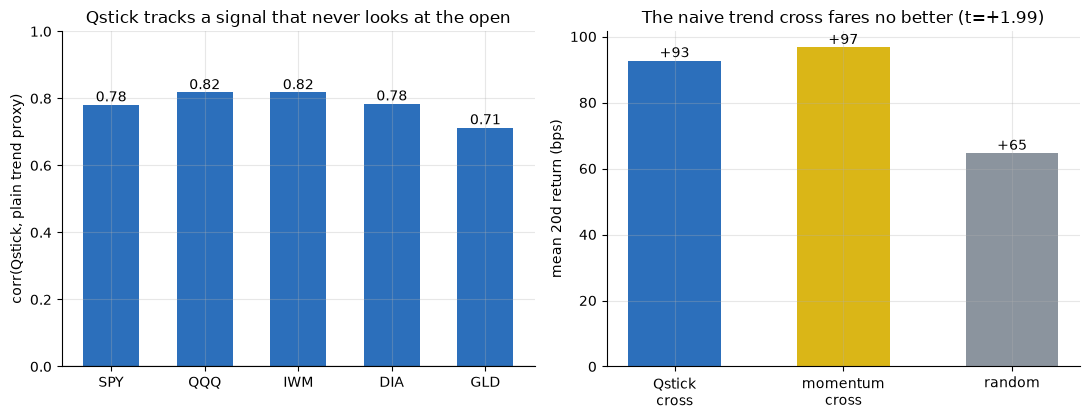

per-ticker corr: {'SPY': 0.781, 'QQQ': 0.818, 'IWM': 0.818, 'DIA': 0.784, 'GLD': 0.713}
momentum-only cross +96.7 bps vs random +64.7 bps, t=+1.99


In [6]:
if HAVE_REAL:
    tickers, corrs = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); tp = st.trend_proxy_stats(bb, smooth=R['smooth'])
        tickers.append(t); corrs.append(tp['corr'])
    tt2, rr2 = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.momentum_cross_entries(bb, n=R['smooth'])
        re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
        tt2.append(st.forward_returns(c,e,20)); rr2.append(st.forward_returns(c,re,20))
    tt2 = np.concatenate(tt2); rr2 = np.concatenate(rr2)
    mom_cross, mom_rnd = tt2.mean()*1e4, rr2.mean()*1e4
    from scipy import stats as _st
    mom_t = _st.ttest_ind(tt2, rr2, equal_var=False)[0]
else:
    tickers = [p[0] for p in R['trend']]; corrs = [p[1] for p in R['trend']]
    mom_cross, mom_rnd, mom_t = R['mom'][1], R['mom'][2], R['mom'][4]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(tickers, corrs, color='#2c6fbb', width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(corrs): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylim(0,1); a1.set_ylabel('corr(Qstick, plain trend proxy)')
a1.set_title('Qstick tracks a signal that never looks at the open')
a2.bar(['Qstick\ncross','momentum\ncross','random'], [cross[2] if HAVE_REAL else R['h20'][2], mom_cross, mom_rnd],
       color=['#2c6fbb', AMBER, GREY], width=.55)
for i,v in enumerate([cross[2] if HAVE_REAL else R['h20'][2], mom_cross, mom_rnd]):
    a2.annotate(f'{v:+.0f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('mean 20d return (bps)'); a2.set_title(f'The naive trend cross fares no better (t={mom_t:+.2f})')
plt.tight_layout(); plt.show()
print('per-ticker corr:', dict(zip(tickers, [round(c,3) for c in corrs])))
print(f'momentum-only cross {mom_cross:+.1f} bps vs random {mom_rnd:+.1f} bps, t={mom_t:+.2f}')

> 💡 In plain words: Qstick correlates with the open-blind trend proxy at **r ≈ 0.78** pooled — strong structural overlap. And when the plain proxy runs the *same* race, it scores **+97 bps** vs **+65 bps** random (Δ = +32 bps, t = 1.99) — itself **short of *t* = 2**. Chande's open/close split adds bar-level noise, not forecasting power, over a trend signal that is *itself* unproven.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic tape with a latent, **mean-reverting** buying-pressure factor (stationary AR(1), no self-referential feedback — an earlier feedback-loop design was tried and made the price path explode, an engineering note, not part of the claim). The null (edge = 0) is checked over **20 seeds** — never a single stream.

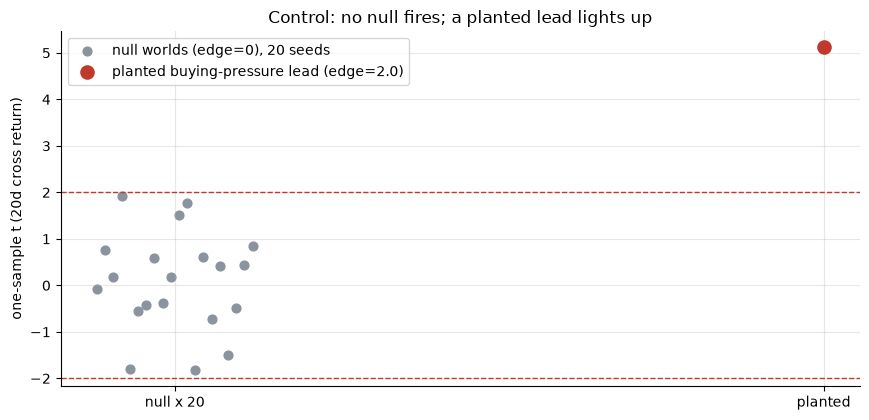

null: mean t = +0.07 (sd 1.07), |t|>=2 in 0/20 seeds  |  planted t = +5.12


In [7]:
null_ts = []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=675 + s_, n_days=8000)
    s = st.summarize(st.forward_returns(px['close'], st.qstick_cross_entries(px, smooth=R['smooth']), 20))
    null_ts.append(s['t'])
null_ts = np.asarray(null_ts)
px, _ = data.synthetic_panel(edge=2.0, seed=675, n_days=8000)
planted_t = st.summarize(st.forward_returns(px['close'], st.qstick_cross_entries(px, smooth=R['smooth']), 20))['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted buying-pressure lead (edge=2.0)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (20d cross return)')
ax.set_title('Control: no null fires; a planted lead lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.07 (sd 1.07) and **never** crosses the bar; a planted, persistent buying-pressure factor reads t = 5.12. The machinery is unbiased — the flat real-tape result is a genuine 'nothing there', not a broken pipeline. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the Qstick up-cross does not beat a drift-matched random baseline (cross − random = -12.8/-11.9/-22.5/+24.5 bps at 5/10/20/60d; Welch t never clears ±2, max |t| = 1.68 at 5d — in the wrong direction). Every one of 5 tickers underperforms its own random baseline at 20 days; an ordering placebo (*p* = 0.81) confirms the body **sequence** carries no information.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the small hole. You'd capture the same drift more cheaply by holding the index.
- **Just a slow trend proxy? `CONFIRMED`** — Qstick correlates at r ≈ 0.78 with a plain trailing-momentum proxy that never uses the open, and even that simpler proxy's own cross barely (Δ = +32.1 bps, t = 1.99 < 2) beats random. The candle-body split is a laggier read of ordinary trend, not an independent forecast.

## 6 · Could you trade it? — there is nothing to trade

The Qstick cross's apparent absolute profit is the unconditional drift of the underlying ETFs, which you obtain more cheaply and more fully by **buying and holding**. The rule trades *less* of the time and, at 3 of 4 horizons, *underperforms* a random entry on top of that — a strictly worse, more expensive way to be sometimes-long. There is no capacity question because there is no edge to scale.

## 7 · Going further

- **Window sweep.** 10-day and 20-day Qstick (other platforms' defaults) only raise the trend-proxy correlation further — longer smoothing windows converge faster on plain momentum, not away from it.
- **The oscillator family.** [423-force-index](../../423-force-index/) and [473-balance-of-power](../../473-balance-of-power/) share the 'who's in control' intuition and land in the same None × Mirage place, via different formulas.
- **Volume-weighted Qstick.** Some variants weight the body by volume (closer to Force Index); the trend-proxy critique would need re-testing on that variant specifically.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*